# 15.4.2 扩散残差与无通量边界

## 学习目标与先修知识

计算一维扩散候选的方程及边界残差（residual），识别只查内点的漏洞。

先修：12.4 一维扩散及无通量边界（no-flux boundary）；15.4.1 残差分项。

## 具体问题

某候选在所有内点都满足扩散方程，但边界允许了额外通量。它是否已经是所声明边值问题的解？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
D=.2;t=.5;x=.3;value=np.exp(-D*np.pi**2*t)*np.cos(np.pi*x);print("解析模式在内部的值：",value)

解析模式在内部的值： 0.21907217109185045


## 模型假设

无量纲（dimensionless）位置 $x\in[0,1]$，时间以 T 为单位，浓度（concentration）以 U/V 为单位；扩散系数（diffusion coefficient） D 的数值对应 1/T（物理长度基准已经归一化）。无通量为两端空间导数（derivative）零。候选 $\phi=e^{-rt}\cos(\pi x)+s x$，$s$ 是浓度单位下的斜率（slope）数值。

## 数学解释与推导

$\partial_t\phi=-r e^{-rt}\cos(\pi x)$，$\partial_{xx}\phi=-\pi^2e^{-rt}\cos(\pi x)$，故内部残差是 $(D\pi^2-r)e^{-rt}\cos(\pi x)$。两端导数为 $s$，因此边界损失为 $s^2$。当 $r=D\pi^2$ 时，无论 $s$ 多大，内部残差都为零；错误的边界仍使候选不符合所声明问题。内点和边界配点（collocation point）不能互相替代。独立网格上的解误差还需与解析模式核对。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def diffusion_parts(points, times, diffusivity, rate, slope):
    """For phi=exp(-rate*t)cos(pi*x)+slope*x on [0,1]."""
    residuals = []
    for x,t in zip(points,times):
        base = math.exp(-rate*t)*math.cos(math.pi*x)
        residuals.append((-rate+diffusivity*math.pi**2)*base)
    pde = sum(value*value for value in residuals)/len(residuals)
    # Spatial derivatives of the cosine vanish at both boundaries.
    boundary = slope*slope
    return [float(pde), float(boundary)]

## 对照实验

改变已声明的条件并比较曲线与数值。

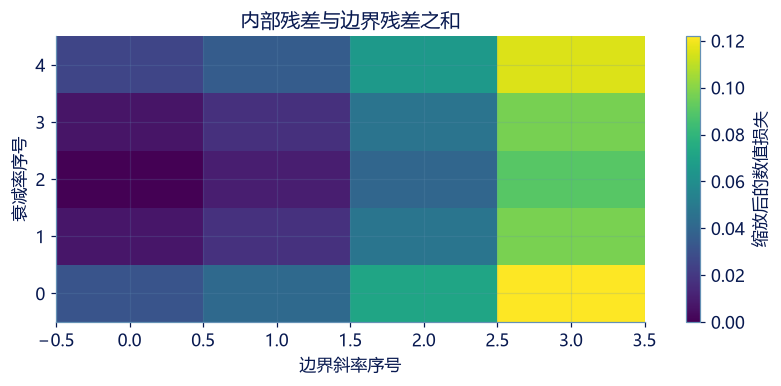

正确速率但错误边界： [0.0, 0.09]


In [4]:
D=.2;xs=np.linspace(0,1,21);ts=np.linspace(0,1,21);rate=D*np.pi**2
levels=np.array([[diffusion_parts(xs,ts,D,r,s) for s in [0.,.1,.2,.3]] for r in np.linspace(rate-.4,rate+.4,5)])
fig,ax=plt.subplots(figsize=(7,3.4));im=ax.imshow(levels[:,:,0]+levels[:,:,1],origin="lower",aspect="auto",cmap="viridis");ax.set(xlabel="边界斜率序号",ylabel="衰减率序号",title="内部残差与边界残差之和");fig.colorbar(im,ax=ax,label="缩放后的数值损失");plt.show()
print("正确速率但错误边界：",diffusion_parts(xs,ts,D,rate,.3))

## 结果解释

图的谷底同时需要正确速率和零边界斜率。仅查 PDE 内部会漏掉沿 $x$ 的线性项；损失低也只是给定配点与函数族的证据，不是一般连续 PDE 的全域证明。 该含斜率候选还改变了 t=0 的初值（initial condition）剖面；若初值固定为余弦模态（mode），也必须把初值损失单独检查。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(diffusion_parts(xs,ts,D,rate,0.),[0.,0.],atol=1e-25)
np.testing.assert_allclose(diffusion_parts(xs,ts,D,rate,.3),[0.,.09],atol=1e-13)
assert diffusion_parts(xs,ts,D,rate+.3,0.)[0]>0
print("解析模态、错误边界与错误速率分别核验通过。")

解析模态、错误边界与错误速率分别核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：内点残差零时

候选 φ=e^{-Dπ²t}cos(πx)+s x，s≠0，内部扩散残差（residual）为零。对无通量问题如何判断？

- **A.** 已证明完全满足问题。
- **B.** 还需检查边界；s≠0 违反零通量条件。
- **C.** 只需增加时间配点（collocation point）。
- **D.** PDE 残差必为无穷。

[作答：内点残差零时](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-boundary-needed)

### 第 2 题 · 单项选择题：有限配点的结论

所有训练配点（collocation point）残差（residual）很小，什么仍需检查？

- **A.** 无需任何评估，已获得连续全域证明。
- **B.** 只看训练损失的总和即可。
- **C.** 独立时空点、边界与解析或数值基线的解误差。
- **D.** 把曲线颜色换成蓝色。

[作答：有限配点的结论](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-collocation-limit)

### 第 3 题 · Python 计算题：扩散候选的空间取值

对给定位置列表和单个时间返回候选 φ=e^{-rt}cos(πx)+s x。

**函数与代码模板**

```python
def solve(
    points: list[float],
    time: float,
    rate: float,
    slope: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `points` | `list[float]` | 区间 [0,1] 的位置。 | 归一化长度 |
| `time` | `float` | 非负时刻。 | T |
| `rate` | `float` | 指数衰减率。 | 1/T |
| `slope` | `float` | 线性空间项系数。 | U/V |

**返回值**

直接返回 values（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 各位置的候选浓度（concentration）数值。 | U/V |

**计算规则**

对每个 x 返回 exp(-rate*time)*cos(pi*x)+slope*x。

**约束与边界**

- 位置位于[0,1]，time≥0，rate≥0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| points | 区间 [0,1] 的位置。 | [0.0, 0.5, 1.0] | 归一化长度 |
| time | 非负时刻。 | 0 | T |
| rate | 指数衰减率。 | 1 | 1/T |
| slope | 线性空间项系数。 | 0 | U/V |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
points = [0.0, 0.5, 1.0]
time = 0.0
rate = 1.0
slope = 0.0

result = solve(points, time, rate, slope)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 各位置的候选浓度（concentration）数值。 | [1.0, 6.123233995736766e-17, -1.0] | U/V |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 6.123233995736766e-17, -1.0]
```

**样例解释**

首例 t=0 且斜率（slope）0，值为 [1,0,-1]（中点允许浮点近零）。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：扩散候选的空间取值](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-diffusion-profile)

### 第 4 题 · Python 计算题：内部与无通量边界残差

返回候选的内部扩散残差（residual）均方和两端相同的导数（derivative）平方。

**函数与代码模板**

```python
def solve(
    points: list[float],
    times: list[float],
    diffusivity: float,
    rate: float,
    slope: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `points` | `list[float]` | 内部配点（collocation point）位置。 | 归一化长度 |
| `times` | `list[float]` | 对应配点时刻。 | T |
| `diffusivity` | `float` | 归一化扩散系数（diffusion coefficient）。 | 1/T |
| `rate` | `float` | 候选衰减率。 | 1/T |
| `slope` | `float` | 空间线性项系数。 | U/V |

**返回值**

直接返回 parts（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `parts` | `list[float]` | 内部 PDE 残差均方、边界导数平方。 | 按分项 |

**计算规则**

候选 exp(-rate*t)*cos(pi*x)+slope*x；内部项为 (∂t候选-diffusivity*∂xx候选)² 平均，边界项为端点空间导数平方。

**约束与边界**

- 位置与时刻等长且至少一个；位置位于[0,1]，时刻非负，扩散系数正。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| points | 内部配点（collocation point）位置。 | [0.0, 0.5, 1.0] | 归一化长度 |
| times | 对应配点时刻。 | [0.0, 0.0, 0.0] | T |
| diffusivity | 归一化扩散系数（diffusion coefficient）。 | 1 | 1/T |
| rate | 候选衰减率。 | ≈ 9.869604 | 1/T |
| slope | 空间线性项系数。 | 0.2 | U/V |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
points = [0.0, 0.5, 1.0]
times = [0.0, 0.0, 0.0]
diffusivity = 1.0
rate = 9.869604401089358
slope = 0.2

result = solve(points, times, diffusivity, rate, slope)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| parts | 内部 PDE 残差均方、边界导数平方。 | [0.0, 0.04000000000000001] | 按分项 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.04000000000000001]
```

**样例解释**

首例内部速率匹配，但 slope=0.2 使边界分项为0.04。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：内部与无通量边界残差](http://127.0.0.1:8000/chapters/15-04-%E7%89%A9%E7%90%86%E7%BA%A6%E6%9D%9F%E5%AD%A6%E4%B9%A0/practice/?question=p15-diffusion-residual)

**进一步阅读**

[Raissi 等](https://www.sciencedirect.com/science/article/pii/S0021999118307125)讨论偏微分方程约束；本节采用已知一维 Neumann 解析模态。